<a href="https://colab.research.google.com/github/robyperez/IA/blob/dev/Copia_de_Taller_precio_del_caf%C3%A9_Serie_temporal_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predición del precio del Café con RNA**

In [ ]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error

**Carga y procesamiento de datos**

In [ ]:
# Cargar el archivo de Excel
archivo_excel = "/content/Precios-area-y-produccion-de-cafe-2025.xlsx"
hoja_trabajo = "2. Precio Interno Mensual"  # Nombre de la hoja que vamos a usar

In [ ]:
# Leer la hoja específica, seleccionando las columnas D y E, y omitiendo las primeras 5 filas
df = pd.read_excel(archivo_excel, sheet_name=hoja_trabajo, usecols="D:E", skiprows=5)

In [ ]:
# Renombrar las columnas para mayor claridad
df.columns = ["Fecha", "Precio"]

In [ ]:
# Convertir la columna de fecha a formato datetime
df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")

In [ ]:
# Mostrar las primeras filas para verificar que la carga fue correcta
print(df.head())

       Fecha  Precio
0 1944-01-01    44.0
1 1944-02-01    44.0
2 1944-03-01    47.0
3 1944-04-01    47.0
4 1944-05-01    47.0


In [ ]:
# Verificar valores nulos
print("Valores nulos por columna:")
print(df.isna().sum())

Valores nulos por columna:
Fecha     0
Precio    0
dtype: int64


**Exploración de datos**

In [ ]:
# Mostrar estadísticas descriptivas
print(df.describe())

                               Fecha        Precio
count                            975  9.750000e+02
mean   1984-07-31 17:52:14.769230784  2.803473e+05
min              1944-01-01 00:00:00  4.400000e+01
25%              1964-04-16 00:00:00  7.130000e+02
50%              1984-08-01 00:00:00  1.548400e+04
75%              2004-11-16 00:00:00  4.014656e+05
max              2025-03-01 00:00:00  3.118571e+06
std                              NaN  4.782613e+05


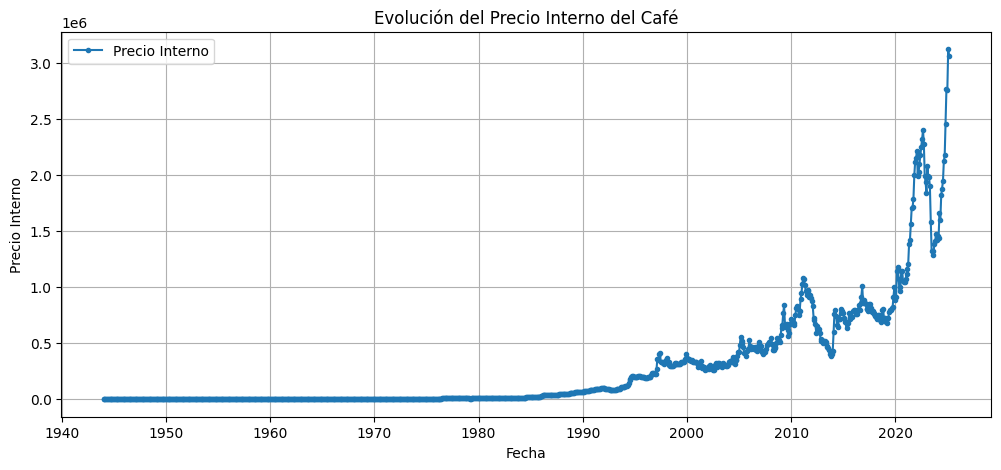

In [ ]:
# Visualización de la Serie de Precios
import matplotlib.pyplot as plt

# Configurar la figura
plt.figure(figsize=(12, 5))

# Graficar la serie temporal
plt.plot(df["Fecha"], df["Precio"], linestyle="-", marker="o", markersize=3, label="Precio Interno")

# Agregar títulos y etiquetas
plt.xlabel("Fecha")
plt.ylabel("Precio Interno")
plt.title("Evolución del Precio Interno del Café")
plt.legend()
plt.grid()

# Mostrar la gráfica
plt.show()


**División en conjuntos de entrenamiento y prueba**

In [ ]:
# Definir el porcentaje de división
train_size = int(len(df) * 0.8)  # 80% para entrenamiento

# División de los datos
data_train = df.iloc[:train_size]
data_test = df.iloc[train_size:]

# Mostrar las primeras filas de cada conjunto
print("Datos de entrenamiento:")
print(data_train.head())

print("\nDatos de prueba:")
print(data_test.head())


Datos de entrenamiento:
       Fecha  Precio
0 1944-01-01    44.0
1 1944-02-01    44.0
2 1944-03-01    47.0
3 1944-04-01    47.0
4 1944-05-01    47.0

Datos de prueba:
         Fecha         Precio
780 2009-01-01  570741.935484
781 2009-02-01  638629.464286
782 2009-03-01  660395.161290
783 2009-04-01  765395.833333
784 2009-05-01  835197.580645


**Preparación de datos con ventana deslizante**

In [ ]:
# Función para crear datos de entrenamiento con ventana deslizante
def sliding_time_series(data, window_size=3):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

# Convertimos los datos en listas
serie_train = data_train["Precio"].tolist()
serie_test = data_test["Precio"].tolist()

# Definimos el tamaño de la ventana
WINDOW_SIZE = 3

# Aplicamos la función
X_train, y_train = sliding_time_series(serie_train, WINDOW_SIZE)
X_test, y_test = sliding_time_series(serie_test, WINDOW_SIZE)

# Mostramos un ejemplo
print("Ejemplo de X_train:", X_train[:5])
print("Ejemplo de y_train:", y_train[:5])


Ejemplo de X_train: [[44. 44. 47.]
 [44. 47. 47.]
 [47. 47. 47.]
 [47. 47. 48.]
 [47. 48. 49.]]
Ejemplo de y_train: [47. 47. 48. 49. 49.]


**Definición y entrenamiento del modelo RNA**

In [ ]:
from sklearn.neural_network import MLPRegressor

# Definimos el modelo con hiperparámetros iniciales
model = MLPRegressor(
    solver='adam',
    activation='relu',
    hidden_layer_sizes=(120, 40, 10),
    max_iter=500,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    tol=1e-21,
    verbose=True
)

# Entrenamos el modelo
model.fit(X_train, y_train)

Iteration 1, loss = 18404015876.80891037
Iteration 2, loss = 16014426272.98865318
Iteration 3, loss = 14417106272.44838333
Iteration 4, loss = 12999938159.85107040
Iteration 5, loss = 11883669485.19763565
Iteration 6, loss = 10994918607.31733513
Iteration 7, loss = 10080847769.38842392
Iteration 8, loss = 9203909121.19339752
Iteration 9, loss = 8340798244.57999992
Iteration 10, loss = 7412157740.70915031
Iteration 11, loss = 6355672056.22998524
Iteration 12, loss = 5180653805.71804333
Iteration 13, loss = 4081342426.12872171
Iteration 14, loss = 2987937543.76516104
Iteration 15, loss = 2072618547.97566485
Iteration 16, loss = 1267040117.05527949
Iteration 17, loss = 682529350.96497667
Iteration 18, loss = 310160344.25790262
Iteration 19, loss = 157615807.63969085
Iteration 20, loss = 140280552.87749022
Iteration 21, loss = 175071620.02317584
Iteration 22, loss = 200671798.63179874
Iteration 23, loss = 195339123.42184421
Iteration 24, loss = 170514630.65254590
Iteration 25, loss = 14097

MLPRegressor(hidden_layer_sizes=(120, 40, 10), learning_rate='adaptive',
             max_iter=500, tol=1e-21, verbose=True)

**Evaluación del Modelo**

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Predecimos los valores del conjunto de prueba
y_pred = model.predict(X_test)

# Calculamos el error cuadrático medio (MSE) y el coeficiente de determinación (R²)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")


Error Cuadrático Medio (MSE): 8289364942.64
Coeficiente de Determinación (R²): 0.9737


**Predicciones futuras**

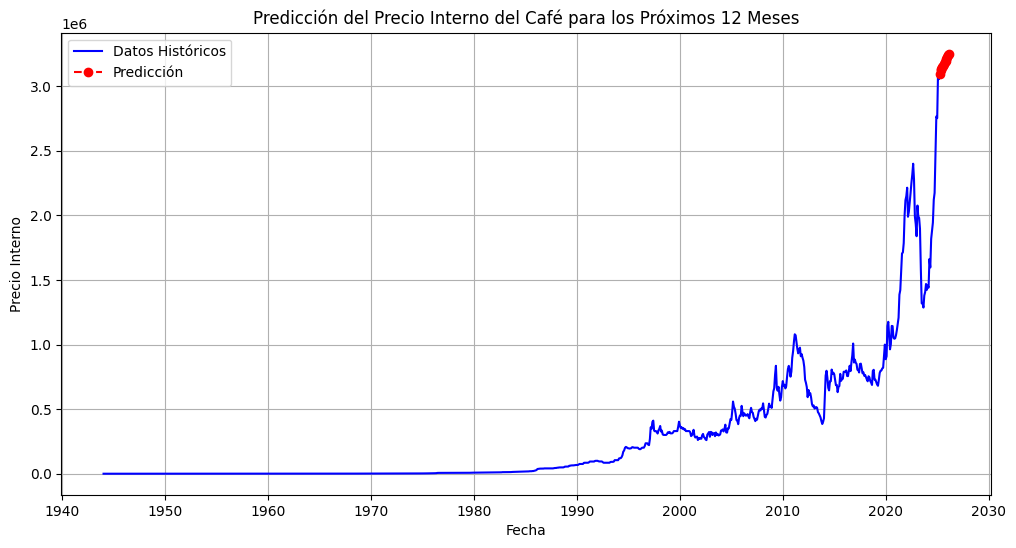

In [ ]:
from datetime import timedelta

# Número de meses a predecir
meses_a_predecir = 12

# Obtener los últimos valores de la serie para iniciar las predicciones
X_pred = X_test[-1].reshape(1, -1)  # Tomamos la última ventana de datos conocida

# Lista para almacenar las predicciones futuras
predicciones_futuras = []

# Generar las predicciones mes a mes
for _ in range(meses_a_predecir):
    y_pred = model.predict(X_pred)[0]  # Predecir el siguiente valor
    predicciones_futuras.append(y_pred)

    # Desplazar la ventana: eliminar el primer valor y agregar la nueva predicción
    X_pred = np.roll(X_pred, -1)
    X_pred[0, -1] = y_pred  # Añadir la nueva predicción al final de la ventana

# Crear un DataFrame con las fechas futuras
ultima_fecha = df['Fecha'].max()  # Última fecha en los datos originales
fechas_futuras = [ultima_fecha + timedelta(days=30 * i) for i in range(1, meses_a_predecir + 1)]
df_predicciones = pd.DataFrame({'Fecha': fechas_futuras, 'Precio Predicho': predicciones_futuras})

# Graficar los datos históricos y las predicciones futuras
plt.figure(figsize=(12, 6))
plt.plot(df['Fecha'], df['Precio'], label="Datos Históricos", color='blue')
plt.plot(df_predicciones['Fecha'], df_predicciones['Precio Predicho'], label="Predicción", color='red', linestyle='dashed', marker='o')
plt.xlabel("Fecha")
plt.ylabel("Precio Interno")
plt.title("Predicción del Precio Interno del Café para los Próximos 12 Meses")
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Mostrar las predicciones futuras con sus fechas correspondientes
predicciones_df = pd.DataFrame({'Fecha': fechas_futuras, 'Precio Predicho': predicciones_futuras})
print(predicciones_df)

        Fecha  Precio Predicho
0  2025-03-31     3.090924e+06
1  2025-04-30     3.122756e+06
2  2025-05-30     3.131764e+06
3  2025-06-29     3.145808e+06
4  2025-07-29     3.158409e+06
5  2025-08-28     3.171434e+06
6  2025-09-27     3.184409e+06
7  2025-10-27     3.197464e+06
8  2025-11-26     3.210566e+06
9  2025-12-26     3.223723e+06
10 2026-01-25     3.236933e+06
11 2026-02-24     3.250198e+06


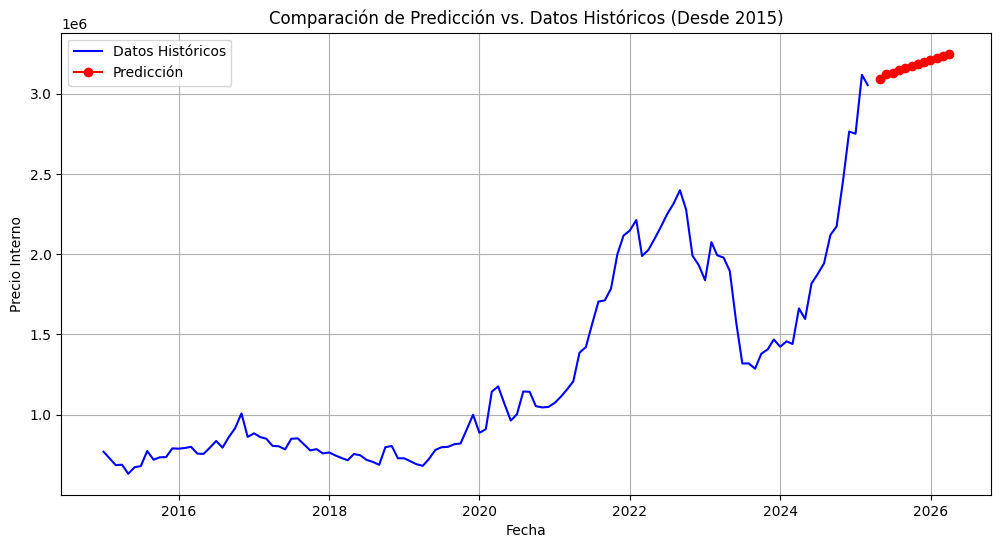

In [ ]:
# Filtrar los datos históricos desde 2015
datos_recientes = df[df['Fecha'] >= '2015-01-01']

# Crear la figura
plt.figure(figsize=(12, 6))

# Graficar los datos históricos recientes
plt.plot(datos_recientes['Fecha'], datos_recientes['Precio'], label="Datos Históricos", color='blue')

# Crear las fechas para las predicciones
fechas_pred = pd.date_range(start=ultima_fecha, periods=meses_a_predecir+1, freq='ME')[1:]


# Graficar las predicciones
plt.plot(fechas_pred, predicciones_futuras, 'ro-', label="Predicción")

# Personalizar la gráfica
plt.xlabel("Fecha")
plt.ylabel("Precio Interno")
plt.title("Comparación de Predicción vs. Datos Históricos (Desde 2015)")
plt.legend()
plt.grid(True)

# Mostrar la gráfica
plt.show()


In [ ]:
X_test = np.array(X_test)
if X_test.ndim == 1:
    X_test = X_test.reshape(-1, 3)  # Asegurar formato correcto

y_pred = model.predict(X_test)
print(y_pred.shape)


(192,)


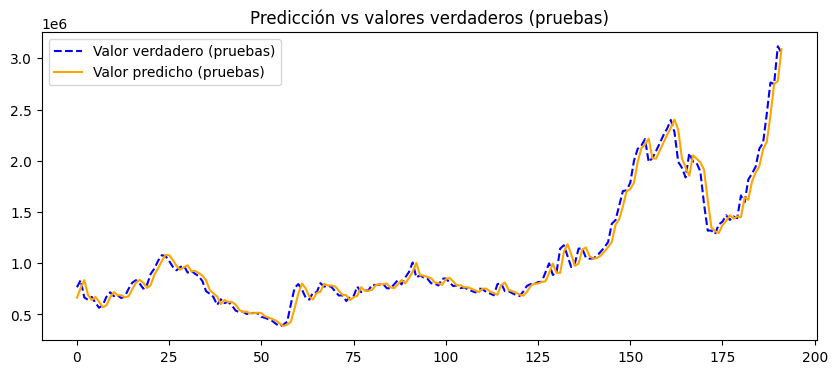

In [ ]:
plt.figure(figsize=(10, 4))

# Graficar valores verdaderos (datos reales de prueba)
plt.plot(y_test, label="Valor verdadero (pruebas)", linestyle="dashed", color="blue")

# Graficar valores predichos (resultados del modelo)
plt.plot(y_pred, label="Valor predicho (pruebas)", linestyle="solid", color="orange")

# Título y etiquetas
plt.title("Predicción vs valores verdaderos (pruebas)")
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Ya tenemos el MSE calculado antes

print(f"Error Absoluto Medio (MAE): {mae:.2f}")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")


Error Absoluto Medio (MAE): 61393.14
Error Porcentual Absoluto Medio (MAPE): 0.0577
Raíz del Error Cuadrático Medio (RMSE): 91045.95


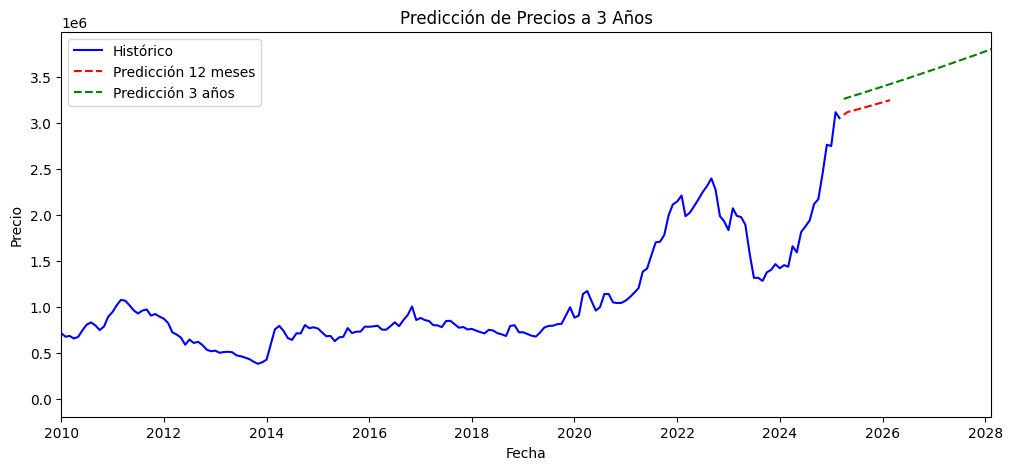

In [ ]:
# Número de meses a predecir (3 años)
meses_a_predecir_3_anios = 36

# Generar nuevas fechas futuras
fechas_futuras_3_anios = [ultima_fecha + timedelta(days=30*i) for i in range(1, meses_a_predecir_3_anios + 1)]

# Inicializar lista para almacenar predicciones
predicciones_futuras_3_anios = []

X_pred_3_anios = X_pred.copy()

# Generar predicciones mes a mes
for _ in range(meses_a_predecir_3_anios):
    y_pred = model.predict(X_pred_3_anios)[0]  # Predecir el siguiente valor
    predicciones_futuras_3_anios.append(y_pred)

    # Actualizar X_pred para la siguiente iteración
    X_pred_3_anios = np.roll(X_pred_3_anios, -1)
    X_pred_3_anios[-1] = y_pred  # Insertar la predicción más reciente

# Crear DataFrame con predicciones
df_predicciones_3_anios = pd.DataFrame({
    "Fecha": fechas_futuras_3_anios,
    "Precio Predicho": predicciones_futuras_3_anios
})

# Graficar
plt.figure(figsize=(12, 5))
plt.plot(df["Fecha"], df["Precio"], label="Histórico", color='blue')
plt.plot(df_predicciones["Fecha"], df_predicciones["Precio Predicho"], 'r--', label="Predicción 12 meses")
plt.plot(df_predicciones_3_anios["Fecha"], df_predicciones_3_anios["Precio Predicho"], 'g--', label="Predicción 3 años")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.title("Predicción de Precios a 3 Años")
plt.legend()
plt.xlim(pd.Timestamp("2010-01-01"), df_predicciones_3_anios["Fecha"].max())
plt.show()


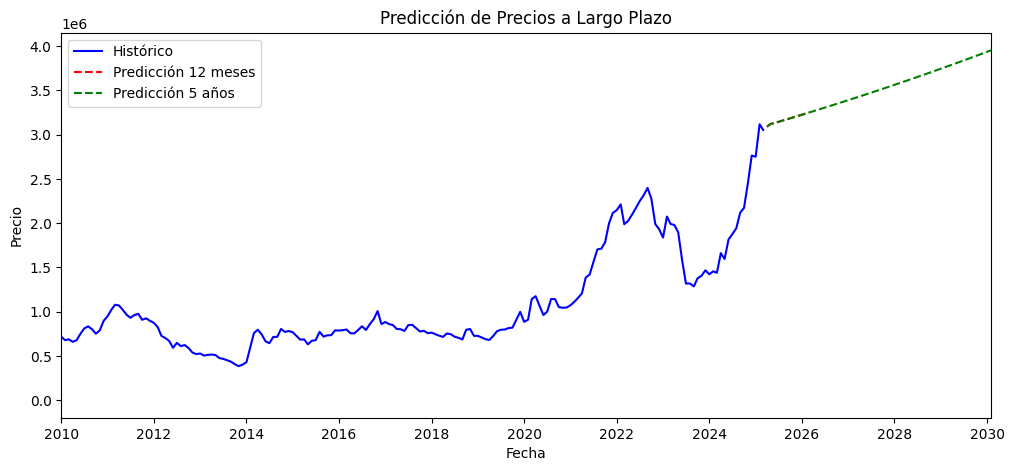

In [ ]:
# Ajustamos la cantidad de meses a predecir
meses_a_predecir = 60

# Crear nuevas fechas para los próximos 5 años
fechas_futuras = [ultima_fecha + timedelta(days=30*i) for i in range(1, meses_a_predecir + 1)]

# Tomar los últimos valores conocidos como punto de partida
X_pred = X_test[-1].reshape(1, -1)

# Lista para almacenar predicciones
predicciones_futuras = []

# Generar las predicciones mes a mes
for _ in range(meses_a_predecir):
    y_pred = model.predict(X_pred)[0]  # Predecir el siguiente valor
    predicciones_futuras.append(y_pred)

    # Crear nueva entrada para el siguiente mes
    X_pred = np.roll(X_pred, -1)
    X_pred[0, -1] = y_pred

# Convertir a DataFrame para mejor visualización
df_predicciones_largo_plazo = pd.DataFrame({"Fecha": fechas_futuras, "Precio Predicho": predicciones_futuras})

# Graficar
plt.figure(figsize=(12, 5))
plt.plot(df["Fecha"], df["Precio"], label="Histórico", color='blue')
plt.plot(df_predicciones["Fecha"], df_predicciones["Precio Predicho"], 'r--', label="Predicción 12 meses")
plt.plot(df_predicciones_largo_plazo["Fecha"], df_predicciones_largo_plazo["Precio Predicho"], 'g--', label="Predicción 5 años")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.title("Predicción de Precios a Largo Plazo")
plt.legend()

# Ajustar la visualización desde el año 2000 o 2010
plt.xlim(pd.Timestamp("2010-01-01"), df_predicciones_largo_plazo["Fecha"].max())

plt.show()
